In [1]:
import scipy.io as sio
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import random
from pathlib import Path
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset
from torchvision import transforms

from torch.optim.lr_scheduler import _LRScheduler
import math

from vit import Encoder

device = 'mps'

In [2]:
bfm = sio.loadmat("01_MorphableModel.mat")

# Mean face (3N, 1) → (N, 3)
mean_shape = bfm["shapeMU"].reshape(-1, 3)
print(mean_shape.shape)  # (~53490, 3)

(53490, 3)


In [3]:
# https://github.com/anilbas/BFMLandmarks/blob/master/Landmarks68_BFM.anl

lm68 = np.array([
22143,22813,22840,23250,44124,45884,47085,47668,48188,48708,
49299,50498,52457,32022,32386,32359,32979,38886,39636,40030,
40238,40433,41172,41368,41578,42011,42646,8291,8305,8314,
8320,6783,7687,8331,8977,9879,1832,3760,5050,6087,4546,
3516,10731,11758,12919,14859,13191,12157,5523,6155,7442,
8345,9506,10799,11199,10179,9277,8374,7471,6566,5909,
7322,8354,9386,10941,9141,8367,7194
]) - 1 

In [4]:
face_68 = mean_shape[lm68]

# normalise by nose
face_68_sub = face_68 - face_68[30] 
face_68_std = np.std(face_68 - face_68[30])

face_68 = face_68_sub / face_68_std 

In [5]:
# 3D landmarks from BFM mean shape
nose_3d = face_68[30]
left_eye_3d = face_68[36:42].mean(axis=0)
right_eye_3d = face_68[42:48].mean(axis=0)
left_mouth_3d = face_68[48]
right_mouth_3d = face_68[54]

FACE_3D = np.stack([
    left_eye_3d,
    right_eye_3d,
    nose_3d,
    left_mouth_3d,
    right_mouth_3d
])  # (5, 3)

FACE_3D

array([[-0.8404071 ,  0.7488272 , -1.0335017 ],
       [ 0.84871596,  0.74976796, -1.0413295 ],
       [ 0.        ,  0.        ,  0.        ],
       [-0.6635814 , -0.9883333 , -0.8614216 ],
       [ 0.65261775, -0.9806842 , -0.8690622 ]], dtype=float32)

In [6]:
# https://github.com/deepinsight/insightface/tree/master/detection/retinaface

def parse_wider_face_landmark_txt(txt_path):
    samples = []
    current_image = None

    with open(txt_path, 'r') as f:
        for line in f:
            line = line.strip()

            if line.startswith('#'):
                # New image
                if current_image is not None:
                    samples.append(current_image)

                image_path = line[2:]  # remove "# "
                current_image = {
                    "image_path": image_path,
                    "faces": []
                }

            else:
                nums = list(map(float, line.split()))
                assert len(nums) == 20, f"Expected 20 values, got {len(nums)}"

                x, y, w, h = map(int, nums[:4])

                lm = nums[4:19]
                landmarks = []
                for i in range(0, 15, 3):
                    lx, ly, v = lm[i:i+3]
                    landmarks.append((lx, ly, int(v)))

                score = nums[19]

                face = {
                    "bbox": [x, y, w, h],
                    "landmarks": landmarks,
                    "score": score
                }

                current_image["faces"].append(face)

        if current_image is not None:
            samples.append(current_image)

    return samples

samples = parse_wider_face_landmark_txt('/Users/saptarshimallikthakur/Downloads/retinaface_gt_v1.1/train/label.txt')
print(len(samples), "images loaded")

12880 images loaded


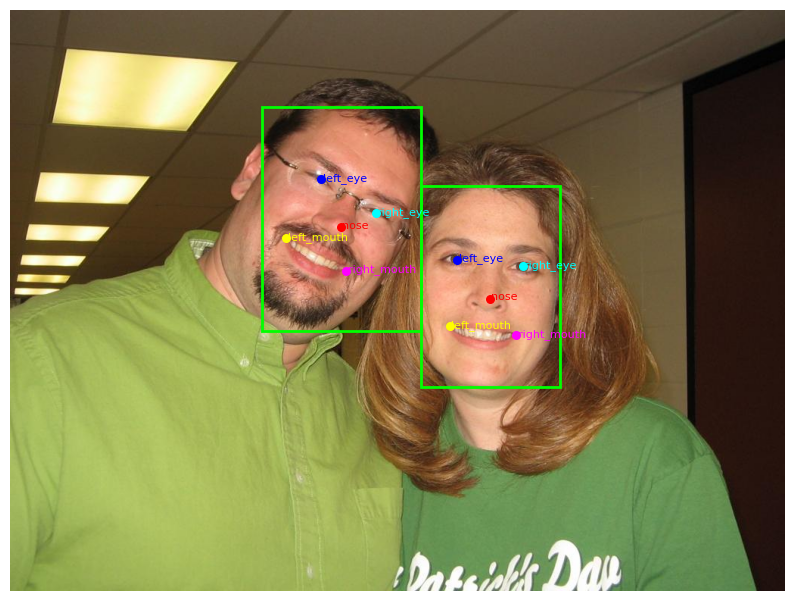

In [7]:
def visualize_sample_plt(sample, image_root, max_faces=None):
    img_path = os.path.join(image_root, sample["image_path"])
    img = Image.open(img_path).convert("RGB")

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)
    ax.axis('off')

    faces = sample["faces"]
    if max_faces is not None:
        faces = faces[:max_faces]

    for face in faces:
        x, y, w, h = face["bbox"]

        # Draw bounding box
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor='lime',
            facecolor='none'
        )
        ax.add_patch(rect)

        # Draw landmarks
        for (lx, ly, v), color, name in zip(
            face["landmarks"],
            LANDMARK_COLORS,
            LANDMARK_NAMES
        ):
            if v != -1:
                ax.scatter(lx, ly, c=color, s=30)
                ax.text(lx + 2, ly + 2, name, fontsize=8, color=color)

    plt.show()
    

LANDMARK_COLORS = [
    'blue',     # left eye
    'cyan',     # right eye
    'red',      # nose
    'yellow',   # left mouth
    'magenta'   # right mouth
]

LANDMARK_NAMES = [
    'left_eye', 'right_eye', 'nose', 'left_mouth', 'right_mouth'
]

samples = parse_wider_face_landmark_txt('/Users/saptarshimallikthakur/Downloads/retinaface_gt_v1.1/train/label.txt')

folder = '/Users/saptarshimallikthakur/Pictures/WIDER_train/images'

visualize_sample_plt(samples[100], folder)

In [8]:
def bbox_xywh_to_xyxy(bbox):
    x, y, w, h = bbox
    return x, y, x + w, y + h

def landmarks_to_crop(landmarks, bbox, crop_size):
    x1, y1, x2, y2 = bbox_xywh_to_xyxy(bbox)

    face_2d = []
    for lx, ly, v in landmarks:
        cx = (lx - x1) / (x2 - x1)
        cy = (ly - y1) / (y2 - y1)
        face_2d.append([cx * crop_size, cy * crop_size])

    return np.array(face_2d, dtype=np.float32)


def estimate_pose(face_3d, face_2d, K):
    face_3d = face_3d.astype(np.float32)
    face_2d = face_2d.astype(np.float32)

    success, rvec, tvec = cv2.solvePnP(
        face_3d,
        face_2d,
        K,
        None,
        flags=cv2.SOLVEPNP_EPNP
    )

    if success:
        success, rvec, tvec = cv2.solvePnP(
            face_3d,
            face_2d,
            K,
            None,
            rvec,
            tvec,
            useExtrinsicGuess=True,
            flags=cv2.SOLVEPNP_ITERATIVE
        )

    if not success:
        return None, None

    R, _ = cv2.Rodrigues(rvec)
    T = tvec.reshape(3)

    return R, T


def process_face(face, face_3d, K, crop_size, min_score=0.4):
    if face["score"] < min_score:
        return None

    face_2d = landmarks_to_crop(
        face["landmarks"],
        face["bbox"],
        crop_size
    )

    R, T = estimate_pose(face_3d, face_2d, K)
    return R, T


def landmarks_to_crop_with_vis(landmarks, bbox, crop_size):
    x, y, w, h = bbox
    x1, y1, x2, y2 = x, y, x + w, y + h

    lms_crop = []
    for lx, ly, v in landmarks:
        if v == -1:
            lms_crop.append([0.0, 0.0, 0])
        else:
            cx = (lx - x1) / (x2 - x1) * crop_size
            cy = (ly - y1) / (y2 - y1) * crop_size
            lms_crop.append([cx, cy, v])

    return np.array(lms_crop, dtype=np.float32)


def valid_landmark_count(landmarks):
    return sum(1 for _, _, v in landmarks if v != -1)

def project_3d(face_3d, R, T, K):
    pts = (R @ face_3d.T + T[:, None]).T
    pts = pts / pts[:, 2:3]
    pts = (K @ pts.T).T[:, :2]
    return pts


In [9]:
dataset = []

MIN_SCORE = 0.5
MIN_VALID_LMS = 4
MAX_REPROJ_ERR = 5 # pixels

CROP_SIZE = 128
f         = CROP_SIZE * 2  # w + h
cx  = cy  = CROP_SIZE / 2  # w/2 and h/2

K = np.array([
    [f, 0, cx],
    [0, f, cy],
    [0, 0, 1]
], dtype=np.float32)

for sample_idx, sample in enumerate(samples):
    for face_idx, face in enumerate(sample["faces"]):

        # 1. score filter
        if face["score"] < MIN_SCORE:
            continue

        # 2. landmark availability filter
        if valid_landmark_count(face["landmarks"]) < MIN_VALID_LMS:
            continue

        # 3. convert landmarks → crop space
        face_2d_crop = landmarks_to_crop_with_vis(
            face["landmarks"],
            face["bbox"],
            CROP_SIZE
        )

        # use only (x,y) for PnP
        face_2d_xy = face_2d_crop[:, :2]

        # 4. estimate pose
        R, T = estimate_pose(FACE_3D, face_2d_xy, K)
        if R is None:
            continue

        # 5. sanity check (optional but HIGHLY recommended)
        if T[2] <= 0:
            continue  # face behind camera = garbage

        # 5. reprojection error filter (CRITICAL)
        proj = project_3d(FACE_3D, R, T, K)
        reproj_err = np.mean(np.linalg.norm(proj - face_2d_xy, axis=1))

        if reproj_err > MAX_REPROJ_ERR:
            continue

        dataset.append({
            "image_path": sample["image_path"],
            "bbox": face["bbox"],
            "landmarks_img": face["landmarks"],
            "landmarks_crop": face_2d_crop.tolist(),
            "R": R.tolist(),
            "T": T.tolist()
        })

    # progress log
    if sample_idx % 100 == 0:
        print(f"Processed {sample_idx}/{len(samples)} images, "
              f"dataset size = {len(dataset)}")


Processed 0/12880 images, dataset size = 0
Processed 100/12880 images, dataset size = 274
Processed 200/12880 images, dataset size = 525
Processed 300/12880 images, dataset size = 877
Processed 400/12880 images, dataset size = 1221
Processed 500/12880 images, dataset size = 1503
Processed 600/12880 images, dataset size = 1633
Processed 700/12880 images, dataset size = 1919
Processed 800/12880 images, dataset size = 2243
Processed 900/12880 images, dataset size = 2557
Processed 1000/12880 images, dataset size = 2960
Processed 1100/12880 images, dataset size = 3276
Processed 1200/12880 images, dataset size = 3681
Processed 1300/12880 images, dataset size = 4124
Processed 1400/12880 images, dataset size = 4509
Processed 1500/12880 images, dataset size = 4860
Processed 1600/12880 images, dataset size = 4996
Processed 1700/12880 images, dataset size = 5073
Processed 1800/12880 images, dataset size = 5175
Processed 1900/12880 images, dataset size = 5269
Processed 2000/12880 images, dataset s

In [10]:
def crop_and_resize(img_path, bbox, crop_size):
    img = Image.open(img_path).convert("RGB")
    x, y, w, h = bbox
    crop = img.crop((x, y, x + w, y + h))
    crop = crop.resize((crop_size, crop_size), Image.BILINEAR)
    return np.array(crop)

def visualize_pose_sample(sample_item, image_root):
    img_path = f"{image_root}/{sample_item['image_path']}"
    bbox = sample_item["bbox"]

    crop = crop_and_resize(img_path, bbox, CROP_SIZE)

    lms_crop = np.array(sample_item["landmarks_crop"])[:, :2]
    R = np.array(sample_item["R"])
    T = np.array(sample_item["T"])

    proj = project_3d(FACE_3D, R, T, K)

    plt.figure(figsize=(4, 4))
    plt.imshow(crop)
    plt.axis("off")

    # GT landmarks
    plt.scatter(
        lms_crop[:, 0],
        lms_crop[:, 1],
        c="red",
        s=40,
        label="GT landmarks"
    )

    # Reprojected landmarks
    plt.scatter(
        proj[:, 0],
        proj[:, 1],
        c="cyan",
        s=30,
        marker="x",
        label="Reprojected"
    )

    for i, name in enumerate(
        ["L-eye", "R-eye", "Nose", "L-mouth", "R-mouth"]
    ):
        plt.text(
            lms_crop[i, 0] + 2,
            lms_crop[i, 1] + 2,
            name,
            color="red",
            fontsize=8
        )

    plt.legend()
    plt.show()


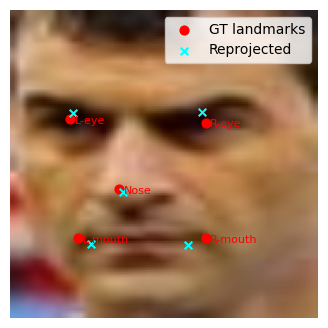

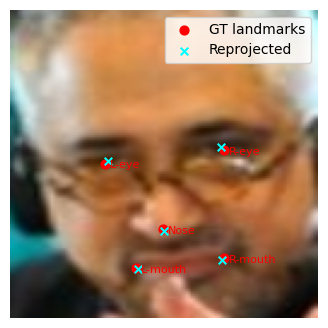

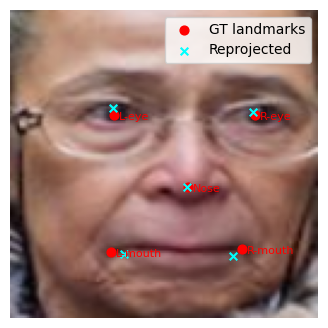

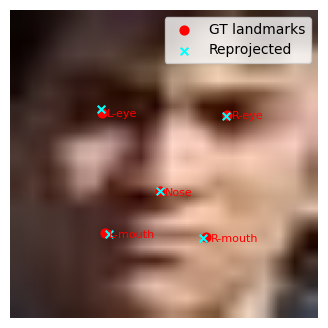

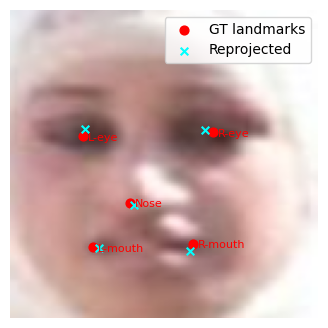

In [11]:
import random
for _ in range(5):
    visualize_pose_sample(random.choice(dataset), folder)

In [12]:
dataset[0]

{'image_path': '0--Parade/0_Parade_marchingband_1_117.jpg',
 'bbox': [69, 359, 50, 36],
 'landmarks_img': [(92.232, 391.397, 1),
  (94.451, 377.451, 1),
  (103.326, 386.326, 0),
  (109.348, 388.228, 0),
  (109.348, 377.134, 0)],
 'landmarks_crop': [[59.47391891479492, 115.1893310546875, 1.0],
  [65.15455627441406, 65.60355377197266, 1.0],
  [87.87455749511719, 97.15911102294922, 0.0],
  [103.29087829589844, 103.9217758178711, 0.0],
  [103.29087829589844, 64.47644805908203, 0.0]],
 'R': [[0.0019147853977000695, -0.9349692497877262, 0.35472360444190465],
  [-0.9789011252930218, 0.07072685342743223, 0.19170367524987608],
  [-0.2043255258085397, -0.3476064069542312, -0.9151070239854097]],
 'T': [0.9064894761690141, 1.0676407207872325, 8.504346669260585]}

In [13]:
class WIDERPoseDataset(Dataset):
    def __init__(self, data, img_dir):
        self.data = data
        self.img_dir = img_dir
        
        # Standard ImageNet normalization
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((CROP_SIZE,CROP_SIZE)),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Load Image
        img_path = os.path.join(self.img_dir, item['image_path'])
        img      = cv2.imread(img_path)
        img      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        x,y,w,h  = item['bbox']
        crop     = img[y:y+h, x:x+w]
        crop     = self.transform(crop)

        # Prepare Labels
        R_mat = np.array(item['R'], dtype=np.float32) # (3,) if Rodrigues or (3,3)
        T = np.array(item['T'], dtype=np.float32) # (3,)

        # Convert Matrix to 6D representation (First 2 columns flattened)
        # R6d = [r11, r21, r31, r12, r22, r32]
        pose_6d = R_mat[:, :2].T.flatten() 
        
        # Combine Pose [6D Rot, 3D Trans] -> 9 values
        label = np.concatenate([pose_6d, T])

        # Ground Truth 2D points for Reprojection Loss
        lms_2d = torch.tensor(item['landmarks_crop'], dtype=torch.float32) # (5, 2)
        
        return {
            "image": crop,           
            "target": torch.tensor(label, dtype=torch.float32),
            "lms_2d": lms_2d                 
        }
    

final_dataset = WIDERPoseDataset(dataset, folder)
dataloader = torch.utils.data.DataLoader(final_dataset, batch_size=32, shuffle=True)

del final_dataset, dataset

In [14]:
EMB_DIM    = 192
NUM_HEADS  = EMB_DIM // 32
PATCH_SIZE = 8
DEPTH      = 6

class VitPose(torch.nn.Module):
    def __init__(self, emb_dim=192):
        super().__init__()
        self.encoder = Encoder(patch_size=PATCH_SIZE, embed_dim=emb_dim, depth=DEPTH, num_heads=NUM_HEADS, mlp_ratio=3)

        num_patches = (CROP_SIZE // PATCH_SIZE) ** 2  
        flattened_dim = num_patches * emb_dim   

        self.norm = torch.nn.LayerNorm(flattened_dim)
        self.head = torch.nn.Sequential(
            torch.nn.Linear(flattened_dim, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32 , 9)  # 6D Rot (6) + 3D Trans (3)
        )

        # --- APPLY INITIALIZATION ---
        self.apply(self._init_weights)
        
        # Specific override for the Head (Optional but recommended for Regression)
        # Initialize the final layer to near-zero to start with a "neutral" prediction
        torch.nn.init.constant_(self.head[-1].weight, 0)
        torch.nn.init.constant_(self.head[-1].bias, 0)

    def _init_weights(self, m):
        """
        ViT weight initialization
        :param m: module
        """
        if isinstance(m, torch.nn.Linear):
            # Truncated Normal (std=0.02) is the standard for ViTs
            torch.nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                torch.nn.init.constant_(m.bias, 0)
        
        elif isinstance(m, torch.nn.LayerNorm):
            torch.nn.init.constant_(m.bias, 0)
            torch.nn.init.constant_(m.weight, 1.0)

    def forward(self, img):
        x    = self.encoder(img) # (B, N, D)
        x    = x.flatten(1)
        x    = self.norm(x)
        pose = self.head(x) # (B,9)
        return pose
    

model = VitPose(EMB_DIM)
model.to(device)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}")

Total params     : 4,648,073
Trainable params : 4,648,073


In [16]:
def compute_rotation_matrix_from_6d(poses):
    """
    Constructs rotation matrix from 6D representation.
    poses: (B, 6)
    Returns: (B, 3, 3)
    """
    x_raw = poses[:, 0:3] # First column
    y_raw = poses[:, 3:6] # Second column

    # Gram-Schmidt Orthogonalization
    x = x_raw / (torch.norm(x_raw, dim=1, keepdim=True) + 1e-8)
    z = torch.cross(x, y_raw, dim=1)
    z = z / (torch.norm(z, dim=1, keepdim=True) + 1e-8)
    y = torch.cross(z, x, dim=1)

    # Stack columns
    x = x.unsqueeze(2)
    y = y.unsqueeze(2)
    z = z.unsqueeze(2)
    matrix = torch.cat((x, y, z), 2) # (B, 3, 3)
    return matrix

def batch_project_3d(points_3d, R, T, K):
    """
    points_3d: (B, 3, N) or (1, 3, N)
    R:         (B, 3, 3)
    T:         (B, 3, 1)
    K:         (B, 3, 3) or (1, 3, 3)
    """
    # 1. Camera Transformation: P_cam = R * X + T
    # bmm = Batch Matrix Multiply
    # R (B,3,3) * points (B,3,N) -> (B,3,N)
    cam_points = torch.bmm(R, points_3d) + T 

    # 2. Perspective Projection: P_uv = K * P_cam
    uv_homo = torch.bmm(K, cam_points)

    # 3. Normalize: u = x/z, v = y/z
    # Avoid div by zero with 1e-8
    uv_points = uv_homo[:, :2, :] / (uv_homo[:, 2:3, :] + 1e-8)
    
    # Returns (B, 2, N)
    return uv_points

class ReprojectionLoss(torch.nn.Module):
    def __init__(self, face_3d_coords, K_matrix):
        super().__init__()
        # Register as buffers so they move to GPU automatically
        self.register_buffer('face_3d', torch.tensor(face_3d_coords, dtype=torch.float32).t().unsqueeze(0)) # (1, 3, N)
        self.register_buffer('K', torch.tensor(K_matrix, dtype=torch.float32).unsqueeze(0)) # (1, 3, 3)

    def forward(self, pred_pose, gt_proj):
        batch_size = pred_pose.shape[0]

        # Expand K and Face3D to match batch size
        # (1, 3, N) -> (B, 3, N)
        face_3d_batch = self.face_3d.repeat(batch_size, 1, 1)
        K_batch       = self.K.repeat(batch_size, 1, 1)

        # Reconstruct Matrices
        pred_R = compute_rotation_matrix_from_6d(pred_pose[:, :6])
        pred_T = pred_pose[:, 6:].unsqueeze(2) # (B, 3, 1)

        # --- USE THE FUNCTION HERE ---
        pred_proj = batch_project_3d(face_3d_batch, pred_R, pred_T, K_batch).permute(0, 2, 1) # (B, N, 2)

        # Slice Ground Truth to match (x, y)
        if gt_proj.shape[-1] == 3:
            gt_proj_2d = gt_proj[:, :, :2] # Drop visibility column
        else:
            gt_proj_2d = gt_proj

        loss = torch.nn.functional.l1_loss(pred_proj, gt_proj_2d)
        return loss
    

class CustomLRScheduler(_LRScheduler):
    def __init__(self, optimizer, total_steps, warmup_steps_ratio, min_lr, max_lr, last_epoch=-1):
        self.total_steps = total_steps
        self.warmup_steps = int(total_steps * warmup_steps_ratio)
        self.min_lr = min_lr
        self.max_lr = max_lr
        super(CustomLRScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        current_step = self.last_epoch
        if current_step < self.warmup_steps:
            lr = self.min_lr + (self.max_lr - self.min_lr) * (current_step / self.warmup_steps)
        else:
            progress = (current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            decay_factor = math.exp(-1.0 * progress)
            lr = self.min_lr + (self.max_lr - self.min_lr) * decay_factor
            lr = max(lr, self.min_lr)
        return [lr for _ in self.base_lrs]
    
EPOCHS = 100
TOTAL_STEPS = len(dataloader)*EPOCHS

LEARNING_RATE_MIN = 1e-6
LEARNING_RATE_MAX = 1e-3
WARMUP_RATIO = 0.01

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE_MAX, betas=(0.9, 0.98), eps=1e-9)

scheduler = CustomLRScheduler(
    optimizer,TOTAL_STEPS,
    warmup_steps_ratio=WARMUP_RATIO,
    min_lr=LEARNING_RATE_MIN,
    max_lr=LEARNING_RATE_MAX
)

proj_loss_fn = ReprojectionLoss(FACE_3D, K).to(device)
mse_loss_fn  = torch.nn.MSELoss().to(device)

In [ ]:
model.train()

for epoch in range(EPOCHS):

    train_total_loss = train_mse_loss = train_proj_loss = 0.0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True, unit='batch')

    for batch in progress_bar:

        imgs          = batch['image'].to(device)
        target        = batch["target"].to(device) 
        lms_2d        = batch['lms_2d'].to(device)                

        pred = model(imgs)                          
        mse_loss  = mse_loss_fn(pred, target)
        proj_loss = 0.01 * proj_loss_fn(pred, lms_2d)

        loss = mse_loss + proj_loss

        train_total_loss  += loss.item()
        train_mse_loss    += mse_loss.item()
        train_proj_loss   += proj_loss.item()

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix(tot_loss=loss.item(), mse_loss=mse_loss.item(), proj_loss=proj_loss.item(), lr=f"{scheduler.get_last_lr()[0]:.6f}")

    loss_tensor    = torch.tensor([train_total_loss, train_mse_loss, train_proj_loss], device=device)
    avg_total_loss = loss_tensor[0].item() / len(dataloader)
    avg_mse_loss   = loss_tensor[1].item() / len(dataloader)
    avg_proj_loss  = loss_tensor[2].item() / len(dataloader)

    print(f"Epoch {epoch+1} | Total_Loss {avg_total_loss:.4f} | MSE_Loss {avg_mse_loss:.4f} | Proj_Loss {avg_proj_loss:.4f} ")
    
    torch.save(model.state_dict(), 'model.pt')

Epoch 1/100: 100%|██████████| 753/753 [04:13<00:00,  2.97batch/s, lr=0.001000, mse_loss=0.149, proj_loss=0.0801, tot_loss=0.229] 


Epoch 1 | Total_Loss 1.0628 | MSE_Loss 0.7492 | Proj_Loss 0.3136 


Epoch 2/100: 100%|██████████| 753/753 [04:22<00:00,  2.87batch/s, lr=0.000990, mse_loss=0.0748, proj_loss=0.0591, tot_loss=0.134]


Epoch 2 | Total_Loss 0.1997 | MSE_Loss 0.1246 | Proj_Loss 0.0751 


Epoch 3/100: 100%|██████████| 753/753 [04:13<00:00,  2.97batch/s, lr=0.000980, mse_loss=0.0836, proj_loss=0.0591, tot_loss=0.143] 


...

Epoch 98 | Total_Loss 0.0298 | MSE_Loss 0.0045 | Proj_Loss 0.0253 


Epoch 99/100: 100%|██████████| 753/753 [04:14<00:00,  2.96batch/s, lr=0.000372, mse_loss=0.00213, proj_loss=0.0213, tot_loss=0.0235]


Epoch 99 | Total_Loss 0.0297 | MSE_Loss 0.0044 | Proj_Loss 0.0252 


Epoch 100/100: 100%|██████████| 753/753 [04:14<00:00,  2.96batch/s, lr=0.000369, mse_loss=0.00306, proj_loss=0.0264, tot_loss=0.0295]

Epoch 100 | Total_Loss 0.0297 | MSE_Loss 0.0045 | Proj_Loss 0.0252 


# INFERENCE

In [17]:
inference_model = VitPose(EMB_DIM)
inference_model.load_state_dict(torch.load("model.pt", map_location=device))
inference_model.to(device)
inference_model.eval()

VitPose(
  (encoder): Encoder(
    (patch_embed): PatchEmbedding(
      (proj): Linear(in_features=192, out_features=192, bias=True)
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (blocks): ModuleList(
      (0-5): 6 x TransformerBlock(
        (norm1): RMSNorm()
        (attn): MultiHeadSelfAttention(
          (qkv): Linear(in_features=192, out_features=576, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=192, out_features=192, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): RMSNorm()
        (mlp): MLP(
          (w_gate): Linear(in_features=192, out_features=576, bias=True)
          (w_value): Linear(in_features=192, out_features=576, bias=True)
          (w_out): Linear(in_features=576, out_features=192, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
  )
  (norm): LayerNorm((49152,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(


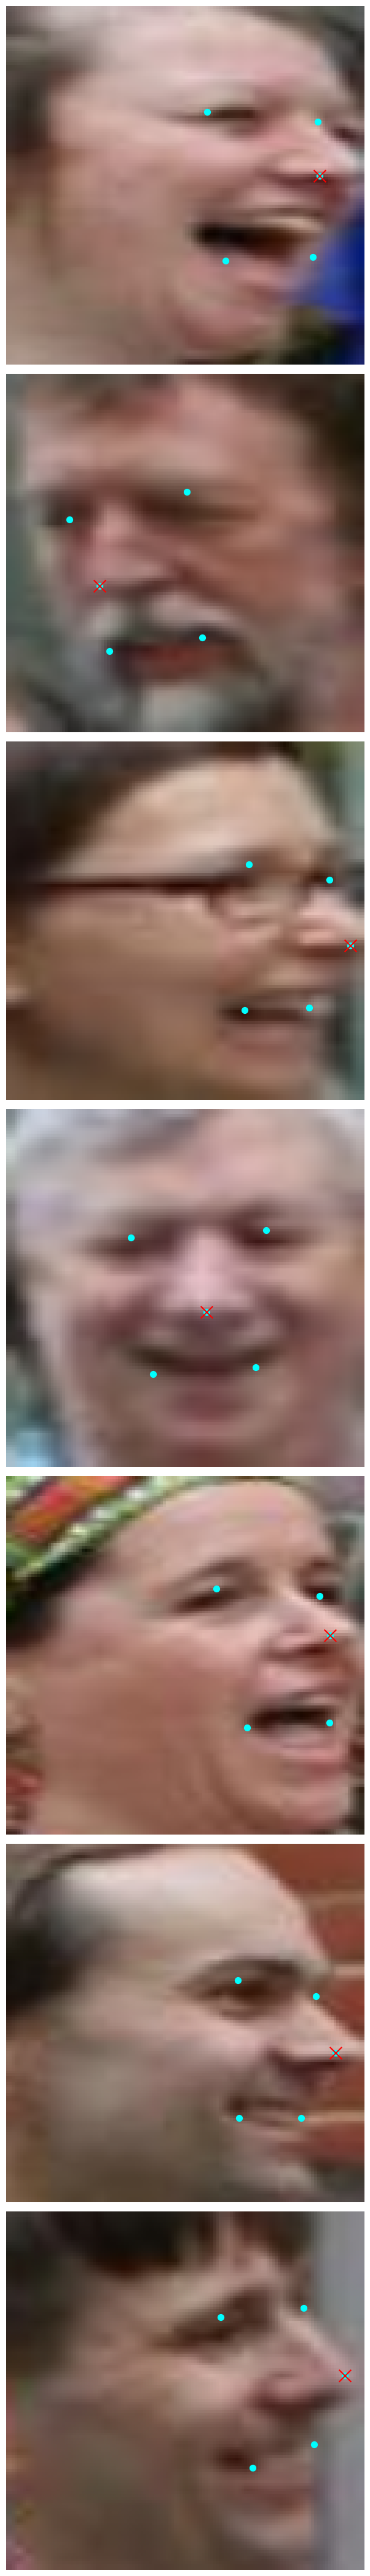

In [18]:
index      = 110
image_root = '/Users/saptarshimallikthakur/Pictures/WIDER_train/images'
sample     = samples[index]
img_path   = os.path.join(image_root, sample["image_path"])

# Standard ImageNet normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((CROP_SIZE,CROP_SIZE)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

FACE_3D_T = torch.tensor(FACE_3D, dtype=torch.float32).to(device).t().unsqueeze(0)
K_T       = torch.tensor(K, dtype=torch.float32).unsqueeze(0).to(device)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

valid_faces = [f for f in sample['faces'] if f['score'] > 0.5]

# Big vertical figure
plt.figure(figsize=(8, 6 * len(valid_faces)))

for idx, face in enumerate(valid_faces):

    x, y, w, h = face['bbox']
    crop      = img[y:y+h, x:x+w]
    crop_t    = transform(crop).unsqueeze(0).to(device)
    viz_crop  = cv2.resize(crop, (CROP_SIZE, CROP_SIZE))

    with torch.no_grad():
        pred_pose = inference_model(crop_t)
        pred_R    = compute_rotation_matrix_from_6d(pred_pose[:, :6])
        pred_T    = pred_pose[:, 6:].unsqueeze(2)

        pred_proj = batch_project_3d(FACE_3D_T, pred_R, pred_T, K_T)
        points    = pred_proj.squeeze(0).cpu().numpy()

    # One row, one plot
    ax = plt.subplot(len(valid_faces), 1, idx + 1)
    ax.imshow(viz_crop)

    ax.scatter(points[0], points[1], s=200, c='cyan', marker='.')

    ax.scatter(points[0, 2], points[1, 2], s=200, c='red', marker='x')

    # ax.set_title(f"Face {idx+1} (Score: {face['score']:.2f})", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()


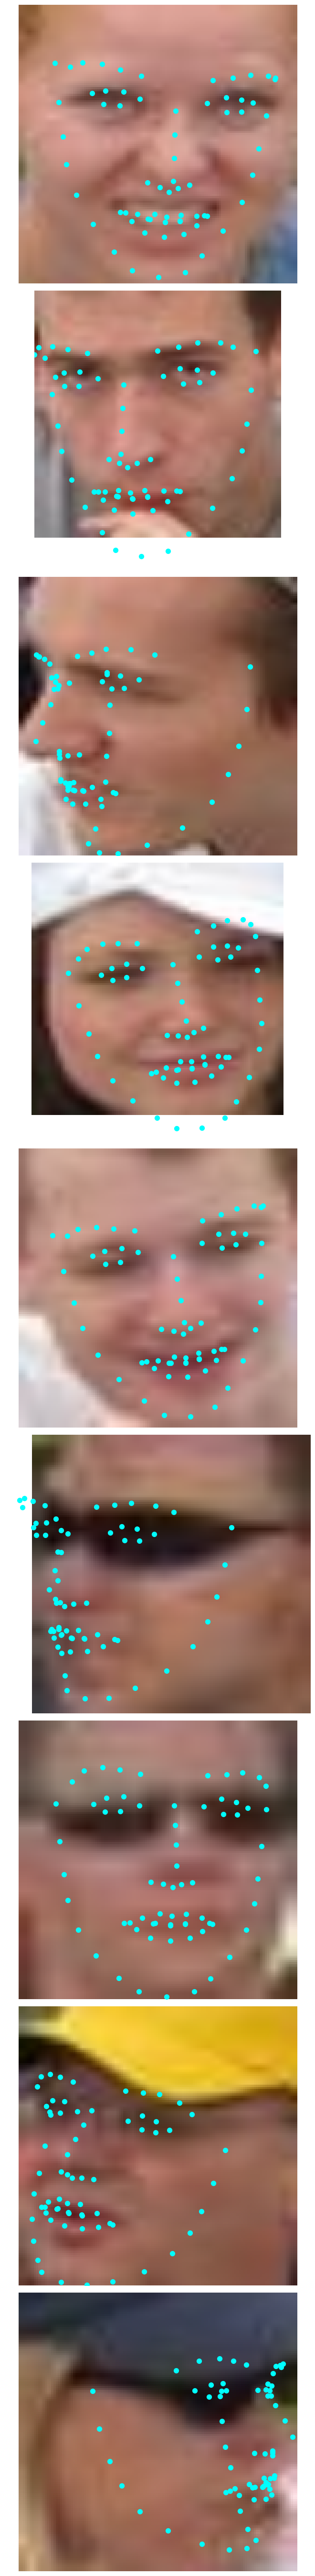

In [19]:
index      = 103
image_root = '/Users/saptarshimallikthakur/Pictures/WIDER_train/images'
sample     = samples[index]
img_path   = os.path.join(image_root, sample["image_path"])

# Standard ImageNet normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((CROP_SIZE,CROP_SIZE)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

FACE_3D_T = torch.tensor(face_68, dtype=torch.float32).to(device).t().unsqueeze(0)
K_T       = torch.tensor(K, dtype=torch.float32).unsqueeze(0).to(device)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

valid_faces = [f for f in sample['faces'] if f['score'] > 0.5]

# Big vertical figure
plt.figure(figsize=(8, 6 * len(valid_faces)))

for idx, face in enumerate(valid_faces):

    x, y, w, h = face['bbox']
    crop      = img[y:y+h, x:x+w]
    crop_t    = transform(crop).unsqueeze(0).to(device)
    viz_crop  = cv2.resize(crop, (CROP_SIZE, CROP_SIZE))

    with torch.no_grad():
        pred_pose = inference_model(crop_t)
        pred_R    = compute_rotation_matrix_from_6d(pred_pose[:, :6])
        pred_T    = pred_pose[:, 6:].unsqueeze(2)

        pred_proj = batch_project_3d(FACE_3D_T, pred_R, pred_T, K_T)
        points    = pred_proj.squeeze(0).cpu().numpy()

    # One row, one plot
    ax = plt.subplot(len(valid_faces), 1, idx + 1)
    ax.imshow(viz_crop)

    ax.scatter(points[0], points[1], s=200, c='cyan', marker='.')

    # ax.scatter(points[0, 2], points[1, 2], s=200, c='red', marker='x')

    # ax.set_title(f"Face {idx+1} (Score: {face['score']:.2f})", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [20]:
def compute_euler_angles_from_rotation_matrices(R):
    """
    R: (B, 3, 3) pytorch tensor or (3, 3) numpy array
    Returns: yaw, pitch, roll in degrees
    """
    # If numpy, convert to tensor for easier handling (or keep pure numpy)
    is_tensor = torch.is_tensor(R)
    
    if is_tensor:
        # Check if singular (Gimbal Lock)
        sy = torch.sqrt(R[:, 0, 0] * R[:, 0, 0] +  R[:, 1, 0] * R[:, 1, 0])
        singular = sy < 1e-6

        x = torch.zeros_like(sy)
        y = torch.zeros_like(sy)
        z = torch.zeros_like(sy)

        # Standard Case
        x[~singular] = torch.atan2(R[~singular, 2, 1], R[~singular, 2, 2])
        y[~singular] = torch.atan2(-R[~singular, 2, 0], sy[~singular])
        z[~singular] = torch.atan2(R[~singular, 1, 0], R[~singular, 0, 0])

        # Singular Case (Gimbal lock)
        x[singular] = torch.atan2(-R[singular, 1, 2], R[singular, 1, 1])
        y[singular] = torch.atan2(-R[singular, 2, 0], sy[singular])
        z[singular] = 0

        # Convert Radians to Degrees
        return x * (180 / math.pi), y * (180 / math.pi), z * (180 / math.pi)
    
    else:
        # Numpy Version
        sy = math.sqrt(R[0,0] * R[0,0] +  R[1,0] * R[1,0])
        singular = sy < 1e-6

        if not singular:
            x = math.atan2(R[2,1] , R[2,2])
            y = math.atan2(-R[2,0], sy)
            z = math.atan2(R[1,0], R[0,0])
        else:
            x = math.atan2(-R[1,2], R[1,1])
            y = math.atan2(-R[2,0], sy)
            z = 0

        return np.array([x, y, z]) * (180 / math.pi)

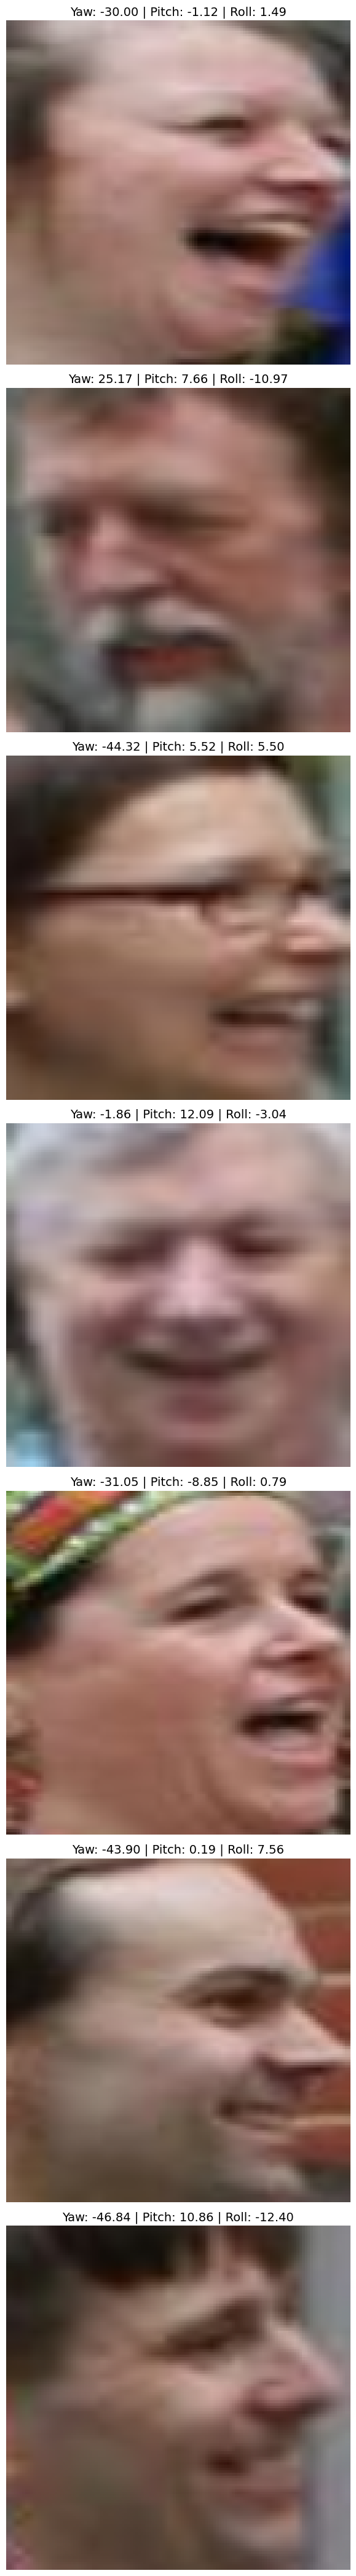

In [23]:
index      = 110
image_root = '/Users/saptarshimallikthakur/Pictures/WIDER_train/images'
sample     = samples[index]
img_path   = os.path.join(image_root, sample["image_path"])

# Standard ImageNet normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((CROP_SIZE,CROP_SIZE)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

FACE_3D_T = torch.tensor(FACE_3D, dtype=torch.float32).to(device).t().unsqueeze(0)
K_T       = torch.tensor(K, dtype=torch.float32).unsqueeze(0).to(device)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

valid_faces = [f for f in sample['faces'] if f['score'] > 0.5]

# Big vertical figure
plt.figure(figsize=(8, 6 * len(valid_faces)))

for idx, face in enumerate(valid_faces):

    x, y, w, h = face['bbox']
    crop      = img[y:y+h, x:x+w]
    crop_t    = transform(crop).unsqueeze(0).to(device)
    viz_crop  = cv2.resize(crop, (CROP_SIZE, CROP_SIZE))

    with torch.no_grad():
        pred_pose = inference_model(crop_t)
        pred_R    = compute_rotation_matrix_from_6d(pred_pose[:, :6])

        pitch, yaw, roll = compute_euler_angles_from_rotation_matrices(pred_R)

    yaw_val   = yaw[0].item()
    pitch_val = pitch[0].item()
    roll_val  = roll[0].item()

    if pitch_val > 0:
        pitch_val -= 180
    else:
        pitch_val += 180

    ax = plt.subplot(len(valid_faces), 1, idx + 1)
    ax.imshow(viz_crop)

    ax.set_title(
        f"Yaw: {yaw_val:.2f} | Pitch: {pitch_val:.2f} | Roll: {roll_val:.2f}",
        fontsize=14
    )

    ax.axis('off')

plt.tight_layout()
plt.show()
